#### imports

27
21
6
21


In [1]:
# SSIM para os histogramas 
# constancia de cor, erro angular
# universal constancia cor

In [2]:
# !conda install numba -y

In [3]:
import os
import cv2
from sklearn.cluster import k_means, KMeans

# from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin, ClusterMixin

# from sklearn.datasets import load_iris
# from sklearn.model_selection import train_test_split
import numpy as np
from numba import njit

import matplotlib.pyplot as plt
import pandas as pd
import json
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics.cluster import adjusted_rand_score  # , ran

# from sklearn import datasets
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
# summation_c = np.array(
#                     [
#                         np.power(distances[i] / distances[i, h], expoente)
#                         for h in range(self.k)
#                     ]
#                 )  # .T

valores = np.ones((10, 5)) * 0.5
# np.expand_dims(0)
np.apply_along_axis(
    arr=np.expand_dims(np.arange(5), 0),
    func1d=lambda x: np.power(valores[0] / valores[0, x], 2),
    axis=0,
)
# np.
# print(np.sum(map(lambda x: np.expand_dims(np.power(valores[0] / valores[0, x], 2), 1), np.arange(5)), 0))

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

#### Pre-processing

In [5]:
class Cleaner(BaseEstimator, TransformerMixin):
  def __init__(self):
    super()
  
  def read_dataset(self, filename):
    X = pd.read_csv(filename, header=None, delim_whitespace=True)
    y = pd.DataFrame({X.shape[1]: np.arange(0, X.shape[0])//200})
    return X, y
  def fit(self, X, y):
    return self
  
  def transform(self, X: pd.DataFrame, y=pd.DataFrame):
    y_lenth = len(y)
    if y_lenth:
      # key = "class"
      # y = pd.DataFrame({key: y})
      values = pd.concat([X, y], axis=1)
    else:
      values = X.copy()

    values = values.dropna()
    values = values.drop_duplicates()
    if y_lenth:
      return values[X.columns.values], values[values.columns.values[-1]]
    return values
  
  def fit_transform(self, X, y=pd.DataFrame):
      return self.fit(X, y).transform(X, y)
  
class Transformer(BaseEstimator, TransformerMixin):
  def __init__(self):
    super()
  def fit(self, X, y=None):
    return self
  def transform(self, X, y=None):
    if type(X) == np.ndarray:
      return X
    return X.values
  def fit_transform(self, X, y=None):
    return self.fit(X, y).transform(X, y)

### Model

##### Metrics

In [6]:
def uqi(img1, img2):
    """
    Calculate the Universal Quality Image Index (UQI) between two images.

    Parameters:
    img1 (numpy array): First image (reference image).
    img2 (numpy array): Second image (image to be compared).

    Returns:
    float: UQI value between -1 and 1.
    """
    assert img1.shape == img2.shape, "Images must have the same dimensions"
    
    N = img1.size
    
    # Means
    mean1 = np.mean(img1)
    mean2 = np.mean(img2)
    
    # Variances and covariance
    var1 = np.var(img1)
    var2 = np.var(img2)
    covar = np.mean((img1 - mean1) * (img2 - mean2))
    
    # UQI calculation
    numerator = 4 * covar * mean1 * mean2
    denominator = (var1 + var2) * (mean1**2 + mean2**2)
    
    if denominator == 0:
        return 1 if numerator == 0 else 0
    
    uqi_value = numerator / denominator
    return uqi_value

def calculate_histogram(image, bins=256):
    """
    Calculate the histogram of an image.
    
    Parameters:
    image (numpy array): Input image.
    bins (int): Number of bins for the histogram.
    
    Returns:
    numpy array: Histogram of the image.
    """
    hist = [cv2.calcHist(images=[image], channels=[channel], mask=None, histSize = [bins], ranges=[0, 256]) \
            for channel in range(3)]
    # hist = cv2.normalize(hist, hist).flatten()
    return hist

def ssim_histogram(hist1, hist2, C1=1e-4, C2=9e-4):
    """
    Calculate SSIM between two histograms.
    
    Parameters:
    hist1 (numpy array): Histogram of the first image.
    hist2 (numpy array): Histogram of the second image.
    C1 (float): Constant to avoid division by zero.
    C2 (float): Constant to avoid division by zero.
    
    Returns:
    float: SSIM value.
    """
    def hist_ssim(hist1, hist2):
        mu_x = np.mean(hist1)
        mu_y = np.mean(hist2)
        sigma_x = np.var(hist1)
        sigma_y = np.var(hist2)
        sigma_xy = np.mean((hist1 - mu_x) * (hist2 - mu_y))
        
        return ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / ((mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x + sigma_y + C2))
    
 
    hssim = [hist_ssim(hist1[channel], hist2[channel]) for channel in range(3)]
    
    return np.mean(hssim)

def metricas(image1, image2):
    uqi_value = uqi(image1, image2)

    hist1 = calculate_histogram(image1)
    hist2 = calculate_histogram(image2)

    # Calcular SSIM entre histogramas
    ssim = ssim_histogram(image1, image2)
    hssim = ssim_histogram(hist1, hist2)
    print(f"SSIM : {ssim:.4f}")
    print(f"SSIM entre histogramas: {hssim:.4f}")
    print(f"UQI: {uqi_value:.4f}")
    return ssim, hssim, uqi_value

import cv2
import numpy as np

def calculate_colorfulness(image):
    (B, G, R) = cv2.split(image.astype("float"))
    rg = np.absolute(R - G)
    yb = np.absolute(0.5 * (R + G) - B)
    
    rg_mean, rg_std = (np.mean(rg), np.std(rg))
    yb_mean, yb_std = (np.mean(yb), np.std(yb))
    
    std_root = np.sqrt((rg_std ** 2) + (yb_std ** 2))
    mean_root = np.sqrt((rg_mean ** 2) + (yb_mean ** 2))
    
    return std_root + (0.3 * mean_root)

# # Supõe-se que image é um array NumPy representando a imagem
# colorfulness = calculate_colorfulness(image)
# print("Colorfulness Index:", colorfulness)
#, assim como a possibilidade de usar as metricas que eduardo/francisco usaram 


In [7]:
class Gaussian:
  def distance(self, g, x, sigma):
    if x.shape[0] == 0 or sigma.shape[0] == 0:
      raise Exception
    
    summatory_distance = np.zeros((*x.shape[:-1], g.shape[0]))
    # def distance(i):
    #     d_sigma = np.square(np.subtract(x, g[i])) / sigma[i]
    #     return (-1/2)*np.sum(d_sigma, 1).T

    # return np.exp(np.apply_along_axis(
    #     arr=np.expand_dims(np.arange(g.shape[0]), 0),
    #     func1d=distance,
    #     axis=0,
    # ))
    for i in range(g.shape[0]):
        d_sigma = np.square(np.subtract(x, g[i])) / sigma[i]
        summatory_distance[:,i] = (-1/2)*np.sum(d_sigma, 1)
    return np.exp(summatory_distance)

class Metrics:
  def mpc(u: np.array):
    # modified partition coefficient
    n, k = u.shape
    f = np.trace(u.dot(u.T)) / n

    mpc = 1 - (k/(k - 1))*(1 - f)
    return mpc
  def ars(y_true, y_pred):
    # adjusted rand score
    return adjusted_rand_score(y_true, y_pred)

In [8]:
x = np.ones((30,3))
g = np.ones((4,3))
Gaussian().distance(g, x, g).shape

(30, 4)

##### Shower

In [9]:
class Shower:
    def show_grafico(self, x):
        _, axes = plt.subplots()
        markers = ["^", "x", "+"]
        p = self.predict(self.G, x)

        for c, (x_1, x_2) in zip(p, x):
            r, g, b, a = (
                0.9 * ((c + 1) / self.num_class),
                0.9 * ((c * 1.1) / self.num_class),
                0.9 * ((c * 1.2) / self.num_class),
                0.1,
            )

            axes.plot(x_1, x_2, "ro", marker=markers[c])

        raio = self.distance_classes() / 2

        for i, (x_1, x_2) in enumerate(self.G):

            plt.plot(x_1, x_2, "go", scalex=0.01, scaley=0.01)
            r, g, b, a = (
                0.9 * ((i + 1) / self.num_class),
                0.9 * ((i * 1.1) / self.num_class),
                0.9 * ((i * 1.2) / self.num_class),
                0.9,
            )
            c = plt.Circle((x_1, x_2), raio, color=(r, g, b, a), fill=False)

            axes.set_aspect(aspect=1, adjustable="datalim", anchor="SW")
            axes.add_artist(c)
        plt.show()

    def show_caracteristicas(self, epoch):
        def cores(colors, title, ax):

            if (colors.max(1) > 1).any():
                colors_formating = (colors.T / colors.max(1)).T
            else:
                colors_formating = colors.copy()
                # Criando uma figura
            # fig, ax = plt.subplots(figsize=(colors.shape[0], 1))

            # Desenhando retângulos coloridos
            for i, color in enumerate(colors_formating):
                ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))

            # Configurando o eixo
            ax.set_xlim(0, colors.shape[0])
            ax.set_ylim(0, 1)
            ax.set_xticks(np.arange(0.5, colors.shape[0] + 0.5))
            formata_numeros = lambda numeros: ",".join(
                ["{:.1f}".format(numero) for numero in numeros]
            )
            ax.set_xticklabels(
                [f"{formata_numeros(colors[i])}" for i in range(colors.shape[0])],
                fontsize=7,
            )
            ax.set_yticks([])
            ax.set_aspect("equal")
            ax.set_title(title)

        fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(self.G.shape[0] * 3, 3))

        cores(self.G, f"prototipo - {epoch}", axs[0])
        cores(self.sigma, f"sigma - {epoch}", axs[1])
        # plt.legend()
        plt.tight_layout(h_pad=0.1, w_pad=0.1)
        plt.show()

    def show_function_objetive(self, data_f, params):
        fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(9, 4))

        # plot box plot
        axs[0].boxplot(data_f)
        # axs[0].set_title('funcão objetivo e m ')
        axs[0].yaxis.grid(True)
        axs[0].set_xticks([y + 1 for y in range(len(data_f))], labels=params)
        axs[0].set_xlabel("m")
        axs[0].set_ylabel("f")

        plt.show()

    def show_labels(self, x, filename):
        # Data
        k, n = x.shape
        plt.figure(figsize=(20, 6))

        # Labels
        xlabs = np.arange(k)
        ylabs = np.arange(n)

        # Heat map
        _, ax = plt.subplots(constrained_layout=True)

        # ax.figure()
        ax.set_axis_off()  # = [0.1, 0.1, 0.8, 0.8] #.add_axes()
        ax.imshow(x)
        if n < 10:
            # Add the labels
            ax.set_xticks(ylabs)
            ax.set_yticks(xlabs)

            # Add the values to each cell
            for i in range(len(xlabs)):
                for j in range(len(ylabs)):
                    _ = ax.text(
                        j,
                        i,
                        round(x[i, j], 1),
                        ha="center",
                        va="center",
                        color=(0, 0, 0),
                    )  # "w"
        if filename:
            plt.savefig(filename, dpi=150)
        plt.show()

    def show_G_S(self, folder):
        # show the values of Gs and S(widths)
        if not os.path.isdir(folder):
            os.makedirs(folder)
        print("Gs")
        self.show_labels(self.G, f"{folder}/G")
        print("S2s")
        self.show_labels(self.sigma, f"{folder}/sigma")

##### Base Model

In [10]:
class Model:
    def __init__(self, loss=Gaussian(), var_type=np.float32) -> None:
        # model base
        self.loss = loss
        np.float32 = var_type

    def predict(self, X, is_preprocessing=False, argmax=True):
        # here we make predict in x
        n = X.shape[0]
        k = self.G.shape[0]

        if is_preprocessing:
            X = self.preprocesssing(X)

        distances = self.loss.distance(self.G, X, self.sigma)
        if argmax:
            return distances.argmax(1)
        return distances
        # if argmax:

    def set_g(self, g):
        self.G = g.copy()

    def set_sigma(self, sigma):
        self.sigma = sigma.copy()

    def preprocesssing(self, X):
        pipeline = Pipeline(
            [
                ("MinMaxScaler", MinMaxScaler()),
                ("Transformer", Transformer()),
            ]
        )

        return pipeline.transform(X)

    def save_model(self, filename):
        # Save the model in json file
        json_object = json.dumps(
            {"G": self.G.tolist(), "sigma": self.sigma.tolist(), "m": self.m}, indent=2
        )  #
        # Writing to sample.json
        folder = "/".join(filename.split("/")[:-1])
        if not os.path.isdir(folder):
            os.makedirs(folder)

        with open(filename, "w") as outfile:
            outfile.write(json_object)

    def load_model(self, filename):
        # Reading from json file
        with open(filename, "r") as openfile:
            json_object = json.load(openfile)
            self.G = np.array(json_object["G"])
            self.sigma = np.array(json_object["sigma"])
            self.m = json_object["m"]


##### FuzzyCMeansGaussianS2

In [11]:
# tá funcionando bonitinho

class FuzzyCMeansGaussianS2(Shower, Model):
    def __init__(
        self,
        num_class,
        epochs,
        threshold,
        loss=Gaussian(),
        m=1.1,
        seeder=None,
        verbose=False,
    ) -> None:
        # load the hiperparams
        super().__init__(loss=loss, var_type=np.float32)
        self.num_class = num_class
        self.m = m
        self.verbose = verbose
        if seeder:
            self.seeder = seeder
            np.random.seed(seeder)

        self.threshold = threshold
        self.epochs = epochs
    # @njit
    def init_g(self, x):
        # here we get random prototipes to train
        unicos = np.unique(x, axis=0)
        args = np.random.choice(unicos.shape[0], self.num_class, replace=False)
        self.G = unicos[args].copy()
    # @njit
    def init_u(self, x):
        # we calcule initial matrix of membership
        # g = self.G.copy()
        # sigma = self.sigma.copy()
        self.n = x.shape[0]
        self.k = self.G.shape[0]

        self.U = np.zeros((self.n, self.k), np.float32)

        distances = 2 - 2 * self.loss.distance(self.G, x, self.sigma)

        expoente = 1 / (self.m - 1)

        for i in range(self.n):
            # summation_c = np.array([(distances[i, h] / distances[i])**expoente for h in range(self.k)])
            # np.divide
            # summation_c = np.array([(distances[i] / distances[i, h])**expoente for h in range(self.k)]) #.T
            ds = distances[i] == 0
            # ds = distances[i] < 1e-5
            if (ds).any():
                self.U[i, ds] = 1.
            else:
                # valores = np.ones((10, 15))*2
                # summation_c = np.apply_over_axes(a=distances[i], func=lambda x, h: np.power(x / x[h], expoente), axes=1)
                # summation_c = np.apply_over_axes(
                #     a=np.arange(self.k), func=lambda x, h: np.power(distances[i] / distances[i, h], expoente), axes=1)
                
                def calc(h):
                    r = distances[i, h] / distances[i]
                    return np.power(r, expoente)

                summation_c = np.apply_along_axis(
                    arr=np.expand_dims(np.arange(self.k), 0),
                    func1d=calc,
                    axis=0,
                ) # lambda h: np.power(distances[i] / distances[i, h], expoente)

                # summation_c = np.array(
                #     [
                #         np.power(distances[i] / distances[i, h], expoente)
                #         for h in range(self.k)
                #     ]
                # )  # .T

                summation_c_i = np.sum(summation_c, 1)


                # print(summation_c_i)
                # print(summation_c_i.shape)
                summation_c_i_1 = np.power(summation_c_i, -1)

                membership_is_nan = np.isnan(summation_c_i_1)

                summation_u = np.sum(summation_c_i_1, where=membership_is_nan == False)

                summation_u_1 = 1 - summation_u
                abs_summation_u_1 = np.abs(summation_u_1)

                if abs_summation_u_1 > 0.01:
                    arg = summation_c_i_1.argmax()
                    summation_c_i_1[arg] = summation_c_i_1[arg] + summation_u_1

                    self.U[i] = summation_c_i_1.copy()
                    raise Exception
                else:
                    self.U[i] = summation_c_i_1.copy()

        self.U_m = np.power(self.U, self.m)
    # @njit
    def init_sigma(self, x):
        # we calcule initial matrix of widths each 1
        self.p = x.shape[1]
        self.k = self.G.shape[0]
        self.sigma = np.ones((self.k, self.p), dtype=np.float32)

    # passo 1
    # @njit 
    def otm_prototivo(self, g, u, x, sigma):
        new_g = g.copy()
        n_g = self.loss.distance(g, x, sigma)

        # def calc_g_i(i):
        #     u_m_g = self.U_m[:, i] * n_g[:, i]  # *
        #     u_m_gx = ((x.T) * u_m_g).T

        #     s_umg = np.sum(u_m_g)
        #     s_umgx = np.sum(u_m_gx, 0)

        #     return s_umgx / s_umg

        for i in range(self.k):

            u_m_g = self.U_m[:, i] * n_g[:, i]  # *
            u_m_gx = ((x.T) * u_m_g).T

            s_umg = np.sum(u_m_g)
            s_umgx = np.sum(u_m_gx, 0)

            new_g[i] = s_umgx / s_umg
        return new_g

    # passo 2
    # @njit 
    def otm_u(self, g, x, sigma):
        new_u = np.zeros((self.n, self.k), dtype=np.float32)

        distances = 2 - 2 * self.loss.distance(g, x, sigma) 

        expoente = 1 / (self.m - 1)
        for i in range(self.n):

            ds = distances[i] == 0
            # ds = distances[i] < 1e-5

            if (ds).any():
                new_u[i, ds] = 1
            else:
                def calc(h):
                    r = distances[i] / distances[i, h]
                    return np.power(r, expoente)

                summation_c = np.apply_along_axis(
                    arr=np.expand_dims(np.arange(self.k), 0),
                    func1d=calc,
                    axis=0,
                )  # .T

                summation_c_i = np.sum(summation_c, 1)

                summation_c_i_1 = np.power(summation_c_i, -1)

                
                # print([f"{v:.2f}" for v in summation_c_i_1])
                # print(np.sum(summation_c_i_1))
                # print(distances[i])
                # print(x[i])
                # print(self.G)
                # raise Exception

                membership_is_nan = np.isnan(summation_c_i_1)

                summation_u = np.sum(summation_c_i_1, where=membership_is_nan == False)

                summation_u_1 = 1 - summation_u
                abs_summation_u_1 = np.abs(summation_u_1)
                # if

                if summation_u == 0 or membership_is_nan.any():
                    count = np.sum(membership_is_nan)  # total nan
                    new_u[i] = np.nan_to_num(summation_c_i_1, nan=summation_u_1 / count)
                elif abs_summation_u_1 > 0.01:
                    arg = summation_c_i_1.argmax()
                    summation_c_i_1[arg] = summation_c_i_1[arg] + summation_u_1

                    new_u[i] = summation_c_i_1.copy()
                else:
                    new_u[i] = summation_c_i_1.copy()
        return new_u
    
    # @njit 
    def otm_sigma(self, x, g, u):
        s = self.sigma.copy()

        # ui = u ** (self.m)
        n_g = self.loss.distance(g, x, s)

        for i in range(self.k):
            # g_i = g[i]
            # ui_per = ui[:, i]

            # g_d = self.loss.distance(g_i, x, s[i])
            e_d = np.power(x - g[i], 2)
            # print(e_d.shape, n_g.shape)
            # raise Exception

            s_cn = e_d.T * (self.U_m[:, i] * n_g[:, i])

            if s_cn.shape[1] != 1:
                ss_cn = np.sum(s_cn, 1).copy()
            else:
                ss_cn = np.squeeze(s_cn, 1).copy()

            s_p = np.prod(ss_cn)
            s_p = s_p ** (1 / self.p)

            s_ij = s_p / ss_cn

            r_r = s_ij[np.isnan(s_ij) == False]
            p_r = np.prod(r_r)

            s_r = np.abs(1 - p_r)

            # verificacao do produtorio para a classe que deve ser 1

            if s_r > 0.1:
                print("entrou")
                # para quando o produtorio de Ss dá diferente de 1
                if r_r.shape[0] == s_ij.shape[0]:
                    s[i] = s_ij / (p_r ** (1 / s_ij.shape[0]))
                else:
                    s_prod = 1 / (p_r ** (1 / s_ij.shape[0]))
                    s[i] = np.nan_to_num(s_ij, copy=True, nan=s_prod)
            elif p_r != 0:
                s[i] = s_ij.copy()

        return s
    
    # @njit 
    def funcao_objetivo(self, x, g, u, sigma):
        # k = g.shape[0]
        s_d = 2 - 2 * self.loss.distance(g, x, sigma)
        u_m = np.power(u, self.m)
        return np.sum(s_d * u_m)
    
    # @njit 
    def atualiza_GUS2(self, g, u, sigma):
        self.G = g
        self.U = u
        self.U_m = np.power(u, self.m)
        self.sigma = sigma
    
    # @njit 
    def fit(self, x, y, verbose=False):
        self.redu = True

        self.init_g(x)
        self.init_sigma(x)
        self.init_u(x)

        j = self.funcao_objetivo(x, self.G, self.U, self.sigma)
        if self.verbose:
            print("epoca:", 0, "funcão objetivo:", j)  # , new_f

        for epoch in range(self.epochs):
            # "passo 1"
            new_sigma = self.otm_sigma(x, self.G, self.U)

            # "passo 2"
            new_g = self.otm_prototivo(self.G, self.U, x, new_sigma)

            # "passo 3"
            new_u = self.otm_u(new_g, x, new_sigma)

            new_j = self.funcao_objetivo(x, new_g, new_u, new_sigma)
            if self.verbose:
                print(f"epoca: {epoch + 1} funcão objetivo: {new_j}")  # f,
                # print(
                #     f"Modified partition coefficient  {Metrics.mpc(self.U)},  {Metrics.ars(y, self.U.argmax(1))}"
                # )  # f,

            # silhouette_score
            if self.verbose and False: # 
                self.show_caracteristicas(epoch)

            dif = np.abs(new_j - j)
            # new_j > j
            if np.isnan(new_j) == True or dif < self.threshold:
                return
            else:
                j = new_j
                self.atualiza_GUS2(new_g, new_u, new_sigma)


##### Trainer

In [12]:
class Trainer(FuzzyCMeansGaussianS2):
    def __init__(
        self,
        num_class,
        epochs,
        threshold,
        model_creator,
        filename,
        loss=Gaussian(),
        m=1.1,
        verbose=False,
        repeat=1,
    ) -> None:
        # load the hiperparams
        super().__init__(num_class, epochs, threshold, loss=loss, m=m)
        self.num_class = num_class
        np.float32 = np.float32
        self.verbose = verbose
        self.threshold = threshold
        self.epochs = epochs
        self.repeat = repeat
        self.model_creator = model_creator
        self.filename = filename
        self.metrics = {
            "objetive_function": [],
            "mpc": [],
            "ars": [],
        }

    def fit(self, X, y):
        j = np.inf

        for i in range(self.repeat):
            model = self.model_creator(
                num_class=self.num_class,
                epochs=self.epochs,
                threshold=self.threshold,
                loss=self.loss,
                m=self.m,
                verbose=self.verbose,
            )
            model._only = False
            model.fit(X, y)
            new_j = model.funcao_objetivo(X, model.G, model.U, model.sigma)
            new_mpc = Metrics.mpc(model.U)
            new_ars = Metrics.ars(y, model.U.argmax(1))

            print(f"repeation: {i + 1} funcão objetivo: {new_j}")
            print(
                f"Modified partition coefficient: {new_mpc},  adjusted rand score: {new_ars}"
            )

            self.metrics["objetive_function"].append(new_j)
            self.metrics["mpc"].append(new_mpc)
            self.metrics["ars"].append(new_ars)

            if new_j < j:
                self.G = model.G
                self.U = model.U
                self.sigma = model.sigma
                j = new_j

        self.save_model(f"./model/{self.m}/{self.filename}")
        self.save(f"./metrics/{self.m}/{self.filename}")

    def save(self, filename):
        if not len(self.metrics["objetive_function"]):
            print("the models is not fit")
            return
        # Save the model in json file
        json_object = json.dumps(self.metrics, indent=2)  #
        # Writing to sample.json
        folder = "/".join(filename.split("/")[:-1])
        if not os.path.isdir(folder):
            os.makedirs(folder)

        with open(filename, "w") as outfile:
            outfile.write(json_object)

##### Custom model

In [13]:
# Definindo a variável de ambiente temporariamente
# os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "4"
# Classe do Modelo Personalizado
class CustomModel(BaseEstimator, ClusterMixin):
    def __init__(self, param1=1, param2=1, **kwargs):
        super(CustomModel).__init__(**kwargs)
        self.param1 = param1
        self.param2 = param2
        self.kmeans = KMeans(n_clusters=self.param1, n_init=10)

    def fit(self, X, y):
        # Implemente aqui o código para treinar o modelo com os parâmetros
        self.kmeans.fit(X, y) 
        

    def predict(self, X):
        # Implemente aqui o código para fazer previsões
        return self.kmeans.predict(X)

    def get_params(self, deep=True):
        return {'param1': self.param1, 'param2': self.param2}

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# Carregando o conjunto de dados Iris
# iris = load_iris()
# X = iris.data
# y = iris.target

# # Dividindo o conjunto de dados em conjuntos de treinamento e teste
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Definindo o modelo personalizado
# custom_model = CustomModel()

# # Definindo o espaço de parâmetros a serem testados
# param_grid = {
#     'param1': list(range(1, 6)),
#     'param2': [0.1, 0.01, 0.001]
# }

# # Criando um objeto GridSearchCV com o modelo personalizado, espaço de parâmetros e métrica de avaliação
# grid_search = GridSearchCV(estimator=custom_model, param_grid=param_grid, cv=5, scoring='rand_score')

# # Ajustando o GridSearchCV aos dados de treinamento
# grid_search.fit(X_train, y_train)

# # Exibindo os melhores parâmetros encontrados
# print("Melhores parâmetros:", grid_search.best_params_)

# # Exibindo a melhor pontuação alcançada
# print("Melhor pontuação:", grid_search.best_score_)

# # Avaliando o desempenho do modelo otimizado nos dados de teste
# accuracy = grid_search.score(X_test, y_test)
# print("Acurácia nos dados de teste:", accuracy)


### colect data

#### eBDtheque_database_v3 Page CYB_COSMOZONE

In [14]:
resultados = []

In [15]:
# from Pill import Image 
from PIL import Image #, ImageDraw, ImageFont

img_path = "./datasets/eBDtheque_database_v3/Pages/SAINTOGAN_PROSPER_ET_LE_MONSTRE_MARIN_016.jpg"

img = Image.open(img_path).convert("RGB")
image_shape_out = 320, 320, 3
# image = img.resize(image_shape_out[:2])
image = np.array(img)
# image_shape_out = image.shape

print(image.shape)
# image = image[:image_shape_out[0],\
#                      :image_shape_out[1], \
#                         :image_shape_out[2]].reshape(-1, image_shape_out[2])
X = image[:image_shape_out[0],\
                     :image_shape_out[1], \
                        :image_shape_out[2]].reshape(-1, image_shape_out[2]) /255
print(X.shape)

(3627, 5311, 3)
(102400, 3)


In [16]:
# image 출력 함수 정의
def show_img_bbox(X, y):
    plt.figure(figsize=(20, 20))
    for i, img in enumerate([X, y]):
        plt.subplot(1, 2, i+1)
        plt.imshow(img)


#### c = 20

##### fit

In [17]:
model = FuzzyCMeansGaussianS2(num_class=20, epochs=50, threshold=.5, verbose=True)
model.fit(X, None)

epoca: 0 funcão objetivo: 66889.59731374806
epoca: 1 funcão objetivo: 305.1516821191254
epoca: 2 funcão objetivo: 226.1178004280918
epoca: 3 funcão objetivo: 209.8513146910111
epoca: 4 funcão objetivo: 195.26734498029728
epoca: 5 funcão objetivo: 191.8891580467454
epoca: 6 funcão objetivo: 182.61322942757468
epoca: 7 funcão objetivo: 179.08169461887468
epoca: 8 funcão objetivo: 171.49920415983615
epoca: 9 funcão objetivo: 163.94145326842963
epoca: 10 funcão objetivo: 153.07925904754413
epoca: 11 funcão objetivo: 144.5604254145641
epoca: 12 funcão objetivo: 139.25929435135515
epoca: 13 funcão objetivo: 135.2860194162168
epoca: 14 funcão objetivo: 132.15060074455016
epoca: 15 funcão objetivo: 129.5348622365675
epoca: 16 funcão objetivo: 127.53300748858568
epoca: 17 funcão objetivo: 125.73627843356171
epoca: 18 funcão objetivo: 124.219806482131
epoca: 19 funcão objetivo: 122.84221946177345
epoca: 20 funcão objetivo: 121.31066933298031
epoca: 21 funcão objetivo: 119.58933975131782
epoca: 2

In [18]:
y = model.predict(X)

In [19]:
model.G

array([[0.00197969, 0.00158701, 0.00913895],
       [0.72800336, 0.63801879, 0.51840397],
       [0.00549165, 0.0032002 , 0.02219889],
       [0.53506303, 0.44183862, 0.33136186],
       [0.21755526, 0.20015166, 0.15458687],
       [0.42773397, 0.42225308, 0.36175795],
       [0.45847037, 0.37366483, 0.2710992 ],
       [0.55204484, 0.55836453, 0.50410084],
       [0.48630262, 0.48507418, 0.42516982],
       [0.04225544, 0.03025396, 0.00873864],
       [0.60516809, 0.50752625, 0.38897547],
       [0.02775792, 0.01943351, 0.0361101 ],
       [0.27816401, 0.25774207, 0.19950521],
       [0.37354506, 0.3606006 , 0.30064848],
       [0.14405287, 0.12743077, 0.1092937 ],
       [0.08404611, 0.07009456, 0.06176435],
       [0.68836768, 0.59567933, 0.47443613],
       [0.65078799, 0.55440319, 0.43219412],
       [0.33330858, 0.30838123, 0.24430766],
       [0.00079388, 0.00099022, 0.00073151]])

In [20]:
model.sigma

array([[0.6857862 , 1.4239777 , 1.0240191 ],
       [0.9977344 , 1.1559919 , 0.8670222 ],
       [0.8516092 , 1.1672806 , 1.0059687 ],
       [0.88845956, 1.0989074 , 1.0242388 ],
       [1.0430127 , 1.2837207 , 0.74686104],
       [0.8615894 , 1.2359756 , 0.9390523 ],
       [0.91171473, 1.0485735 , 1.0460253 ],
       [1.0777335 , 1.1105156 , 0.8355336 ],
       [0.9239763 , 1.2520933 , 0.86437553],
       [0.74437517, 1.0205714 , 1.31633   ],
       [0.9223109 , 1.0613747 , 1.0215367 ],
       [1.0042038 , 0.97438735, 1.0219896 ],
       [0.85244673, 1.5377985 , 0.76283973],
       [0.9851225 , 1.1963682 , 0.8484865 ],
       [1.0387357 , 1.1178024 , 0.86125135],
       [1.0381272 , 1.0076506 , 0.9559594 ],
       [1.0561612 , 1.0356734 , 0.91421217],
       [1.0534573 , 1.0158048 , 0.9344861 ],
       [0.69822544, 1.7664176 , 0.8107948 ],
       [1.1805105 , 1.6749811 , 0.50573176]], dtype=float32)

In [21]:
y_image = (model.G[y].reshape(image_shape_out)*255).astype(np.uint8)

In [22]:
import cv2

filename = img_path.split("/")[-1]
set_name = "results/minimal_v3/cmeans/comics/"
dir_out_model = f"{set_name}model/20/model.json"
model.save_model(dir_out_model)

print(str.upper(filename.split(".")[-1]))
dir_out_img = f"{set_name}imgs/20/"
if not os.path.isfile(dir_out_img):
    os.makedirs(dir_out_img, exist_ok=True)
Image.fromarray(y_image).save(f"{dir_out_img}{filename}")
ssim, hssim, q = metricas(
    image[: image_shape_out[0], : image_shape_out[1], : image_shape_out[2]], y_image
)
resultados.append([ssim, hssim, q])

JPG
SSIM : 0.8045
SSIM entre histogramas: 0.2379
UQI: 0.9971


##### show

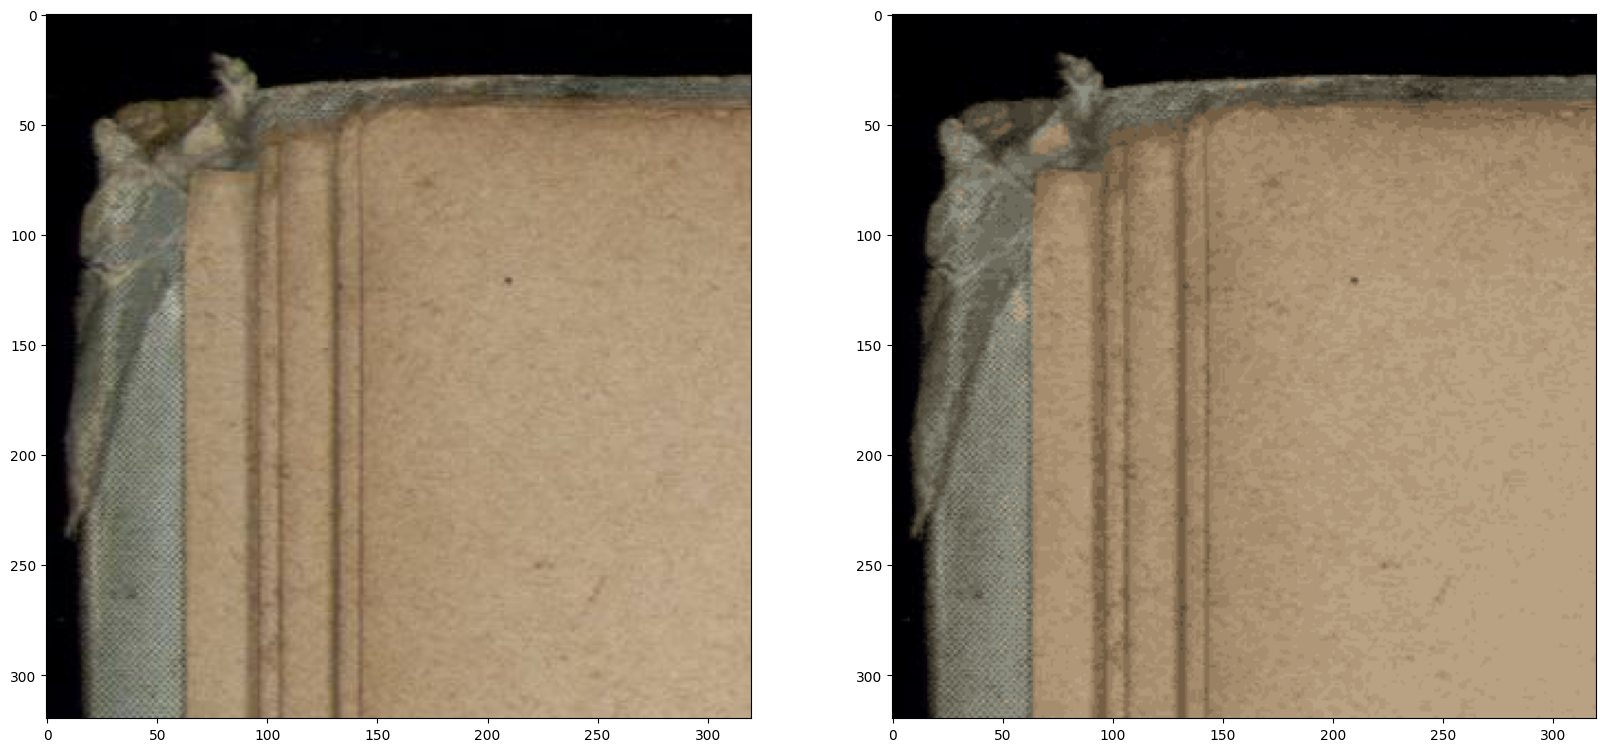

In [23]:
show_img_bbox(image[:image_shape_out[0],\
                     :image_shape_out[1], \
                        :image_shape_out[2]], y_image)

#### c = 10

##### fit

In [24]:
model = FuzzyCMeansGaussianS2(num_class=10, epochs=50, threshold=.5, verbose=True)
model.fit(X, None)

epoca: 0 funcão objetivo: 36850.32638279827
epoca: 1 funcão objetivo: 1280.9978663250693
epoca: 2 funcão objetivo: 412.22743488388903
epoca: 3 funcão objetivo: 278.7956653246999
epoca: 4 funcão objetivo: 235.1330740842803
epoca: 5 funcão objetivo: 218.94911836414678
epoca: 6 funcão objetivo: 212.31345330554404
epoca: 7 funcão objetivo: 207.53896116887861
epoca: 8 funcão objetivo: 205.0474083533471
epoca: 9 funcão objetivo: 202.0450363274239
epoca: 10 funcão objetivo: 201.00556178037624
epoca: 11 funcão objetivo: 197.7919120483337
epoca: 12 funcão objetivo: 196.81593153370957
epoca: 13 funcão objetivo: 193.2545727094597
epoca: 14 funcão objetivo: 192.251570097273
epoca: 15 funcão objetivo: 188.99154595461286
epoca: 16 funcão objetivo: 187.28183816530043
epoca: 17 funcão objetivo: 183.29629619536783
epoca: 18 funcão objetivo: 178.03722948373766
epoca: 19 funcão objetivo: 169.95241902810915
epoca: 20 funcão objetivo: 163.53133476099552
epoca: 21 funcão objetivo: 160.62693244410337
epoca: 

In [25]:
model.G

array([[0.65025971, 0.55566807, 0.43458691],
       [0.38576054, 0.35690114, 0.2874812 ],
       [0.28800748, 0.26709641, 0.20858727],
       [0.00447018, 0.00328682, 0.01109608],
       [0.50599471, 0.50879318, 0.45215886],
       [0.72935882, 0.64010409, 0.52112095],
       [0.59231022, 0.49490456, 0.3775663 ],
       [0.69122243, 0.59951931, 0.47882534],
       [0.47151872, 0.42239043, 0.33733756],
       [0.14564919, 0.12930716, 0.10740237]])

In [26]:
model.sigma

array([[1.020606  , 1.2260494 , 0.7991603 ],
       [0.83967316, 1.4851321 , 0.80190814],
       [0.8617654 , 1.1947848 , 0.9712282 ],
       [0.8176199 , 1.4008706 , 0.8730729 ],
       [1.0779583 , 1.0746679 , 0.86322445],
       [0.7986789 , 1.3317118 , 0.9401942 ],
       [0.9253702 , 1.0024229 , 1.0780365 ],
       [0.9003183 , 1.2376951 , 0.8974086 ],
       [0.65921485, 2.0693197 , 0.73307   ],
       [0.8827692 , 0.96859294, 1.1695304 ]], dtype=float32)

In [27]:
y = model.predict(X)

In [28]:
y_image = (model.G[y].reshape(image_shape_out)*255).astype(np.uint8)

In [29]:
image.shape, y_image.shape

((3627, 5311, 3), (320, 320, 3))

import cv2
filename = img_path.split("/")[-1]
set_name = "results/minimal_v3/cmeans/comics/"
model.save_model(dir_out_model)

print(str.upper(filename.split(".")[-1]))
dir_out_img = f"{set_name}imgs/20/"
if not os.path.isfile(dir_out_img):
    os.makedirs(dir_out_img, exist_ok=True)
Image.fromarray(y_image).save(f"{dir_out_img}{filename}", quality=90)
ssim, hssim, q = metricas(image, y_image)
resultados.append([ssim, hssim, q])

In [30]:
filename = img_path.split("/")[-1]
set_name = "results/minimal_v3/cmeans/comics/"
model.save_model(f"{set_name}model/10/model.json")

dir_out_img = f"{set_name}imgs/10/"
if not os.path.isfile(dir_out_img):
    os.makedirs(dir_out_img, exist_ok=True)

Image.fromarray(y_image).save(f"{dir_out_img}{filename}")
ssim, hssim, q = metricas(
    image[: image_shape_out[0], : image_shape_out[1], : image_shape_out[2]], y_image
)
resultados.append([ssim, hssim, q])

SSIM : 0.5731
SSIM entre histogramas: 0.1961
UQI: 0.9949


In [31]:
image[:2, :2], image.astype(np.float32)[:2, :2]

(array([[[0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0]]], dtype=uint8),
 array([[[0., 0., 0.],
         [0., 0., 0.]],
 
        [[0., 0., 0.],
         [0., 0., 0.]]], dtype=float32))

##### show

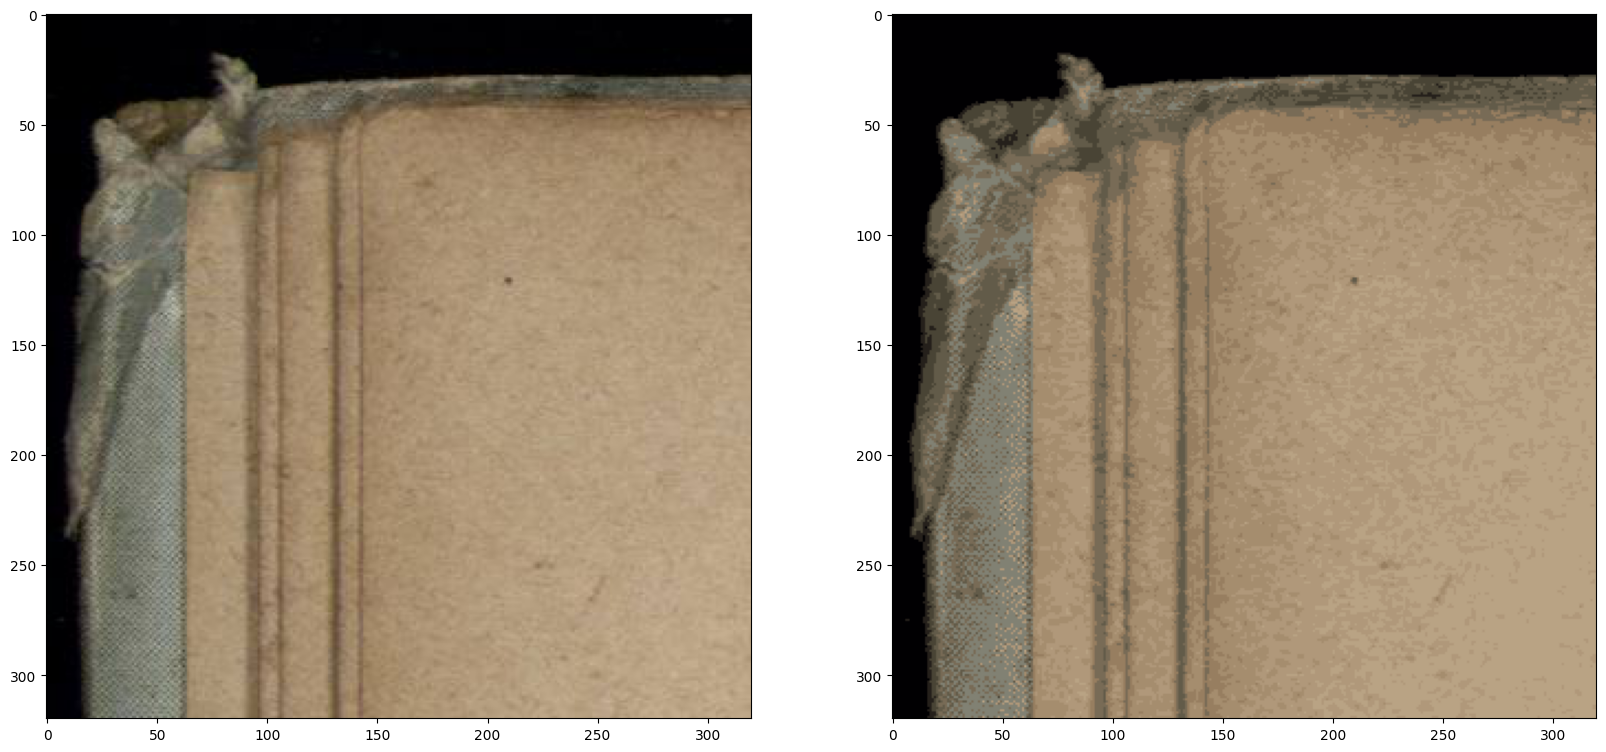

In [32]:
show_img_bbox(image[:image_shape_out[0],\
                     :image_shape_out[1], \
                        :image_shape_out[2]], y_image)

In [33]:
# time change
# new row
# new column
# pure grid
# ecs_insert
# whole_row
# whole_column


#### wikiart High_Renaissance leonardo da vinci mona lisa

In [34]:
# from Pill import Image 
from PIL import Image, ImageDraw, ImageFont
import numpy as np

img_path = "./datasets/wikiart/High_Renaissance/leonardo-da-vinci_mona-lisa.jpg"
image_shape_out = 640, 640, 3
img = Image.open(img_path).convert("RGB")
# img = img.resize(image_shape_out[:2])
image = np.array(img)
# image_shape_out = image.shape

print(image.shape)
X = image[:image_shape_out[0],\
                     :image_shape_out[1], \
                        :image_shape_out[2]].reshape(-1, image_shape_out[2]) /255
print(X.shape)

(4289, 2835, 3)
(409600, 3)


In [35]:
# image 출력 함수 정의
def show_img_bbox(X, y):
    plt.figure(figsize=(20, 20))
    for i, img in enumerate([X, y]):
        plt.subplot(1, 2, i+1)
        plt.imshow(img)


#### c = 20

##### fit

In [36]:
model = FuzzyCMeansGaussianS2(num_class=20, epochs=50, threshold=.5, verbose=True)
model.fit(X, None)

epoca: 0 funcão objetivo: 78108.76344547622
epoca: 1 funcão objetivo: 1298.5734302302494
epoca: 2 funcão objetivo: 906.2916559913373
epoca: 3 funcão objetivo: 687.592177505486
epoca: 4 funcão objetivo: 641.7563921456623
epoca: 5 funcão objetivo: 603.0412163389324
epoca: 6 funcão objetivo: 580.0862577531424
epoca: 7 funcão objetivo: 572.4124029852708
epoca: 8 funcão objetivo: 563.1699885751716
epoca: 9 funcão objetivo: 559.6239325725181
epoca: 10 funcão objetivo: 555.2365154064842
epoca: 11 funcão objetivo: 553.4606683615689
epoca: 12 funcão objetivo: 550.6577180370109
epoca: 13 funcão objetivo: 549.5285364240052
epoca: 14 funcão objetivo: 547.4127292152557
epoca: 15 funcão objetivo: 546.3847069105854
epoca: 16 funcão objetivo: 544.6034660701301
epoca: 17 funcão objetivo: 543.6454564022455
epoca: 18 funcão objetivo: 542.2286119149165
epoca: 19 funcão objetivo: 541.4177668853229
epoca: 20 funcão objetivo: 540.3117185867696
epoca: 21 funcão objetivo: 539.5751262053819
epoca: 22 funcão obj

In [37]:
model.G

array([[0.36953466, 0.29552267, 0.09617951],
       [0.55128295, 0.46620248, 0.18900112],
       [0.64422942, 0.53223189, 0.18917325],
       [0.59720575, 0.50720932, 0.21205951],
       [0.63344188, 0.5442151 , 0.24781124],
       [0.52916943, 0.43243955, 0.13865534],
       [0.5968313 , 0.48645136, 0.15696804],
       [0.69172221, 0.58887793, 0.26637563],
       [0.80342326, 0.69843888, 0.35735668],
       [0.44096758, 0.35354334, 0.11507747],
       [0.49526079, 0.44399296, 0.20943157],
       [0.47636972, 0.39639796, 0.15324573],
       [0.77959568, 0.6614716 , 0.29138202],
       [0.56298474, 0.50068916, 0.25359993],
       [0.6875716 , 0.57020222, 0.21443297],
       [0.3845478 , 0.39728623, 0.20106767],
       [0.72266839, 0.6259077 , 0.3192648 ],
       [0.7405549 , 0.61887896, 0.24556075],
       [0.48454403, 0.52384179, 0.31327054],
       [0.64607704, 0.5709477 , 0.30599138]])

In [38]:
model.sigma

array([[0.89162767, 1.1855495 , 0.9460123 ],
       [1.0891322 , 0.98489016, 0.9322483 ],
       [1.0348042 , 1.0993096 , 0.8790666 ],
       [1.0211747 , 0.97637516, 1.0029591 ],
       [0.9173589 , 1.0739374 , 1.0150367 ],
       [1.0346609 , 1.1165906 , 0.8655815 ],
       [0.9518546 , 1.0456327 , 1.0047319 ],
       [0.9759413 , 1.0263307 , 0.99836415],
       [0.97064775, 1.2049888 , 0.8549788 ],
       [0.99130964, 1.1492871 , 0.8777324 ],
       [0.96195036, 0.9989027 , 1.0406966 ],
       [1.0422887 , 1.1055633 , 0.86781746],
       [0.98329794, 1.11213   , 0.9144486 ],
       [1.000303  , 0.99277645, 1.006971  ],
       [0.9251476 , 1.1531051 , 0.9373895 ],
       [0.90699923, 0.9478519 , 1.1631953 ],
       [1.0412089 , 1.2586902 , 0.7630329 ],
       [1.0899093 , 1.1588864 , 0.7917148 ],
       [0.9678726 , 1.2579052 , 0.82136065],
       [0.92926496, 1.236592  , 0.87022984]], dtype=float32)

In [39]:
y = model.predict(X)

In [40]:
y_image = (model.G[y].reshape(image_shape_out)*255).astype(np.uint8)

In [42]:
filename = img_path.split("/")[-1]
set_name = "results/minimal_v3/cmeans/art/"
model.save_model(f"{set_name}model/20/model.json")

dir_out_img = f"{set_name}imgs/20/"
if not os.path.isfile(dir_out_img):
    os.makedirs(dir_out_img, exist_ok=True)

Image.fromarray(y_image).save(f"{dir_out_img}{filename}")
ssim, hssim, q = metricas(
    image[: image_shape_out[0], : image_shape_out[1], : image_shape_out[2]], y_image
)
resultados.append([ssim, hssim, q])

SSIM : 0.9654
SSIM entre histogramas: 0.2443
UQI: 0.9940


##### show

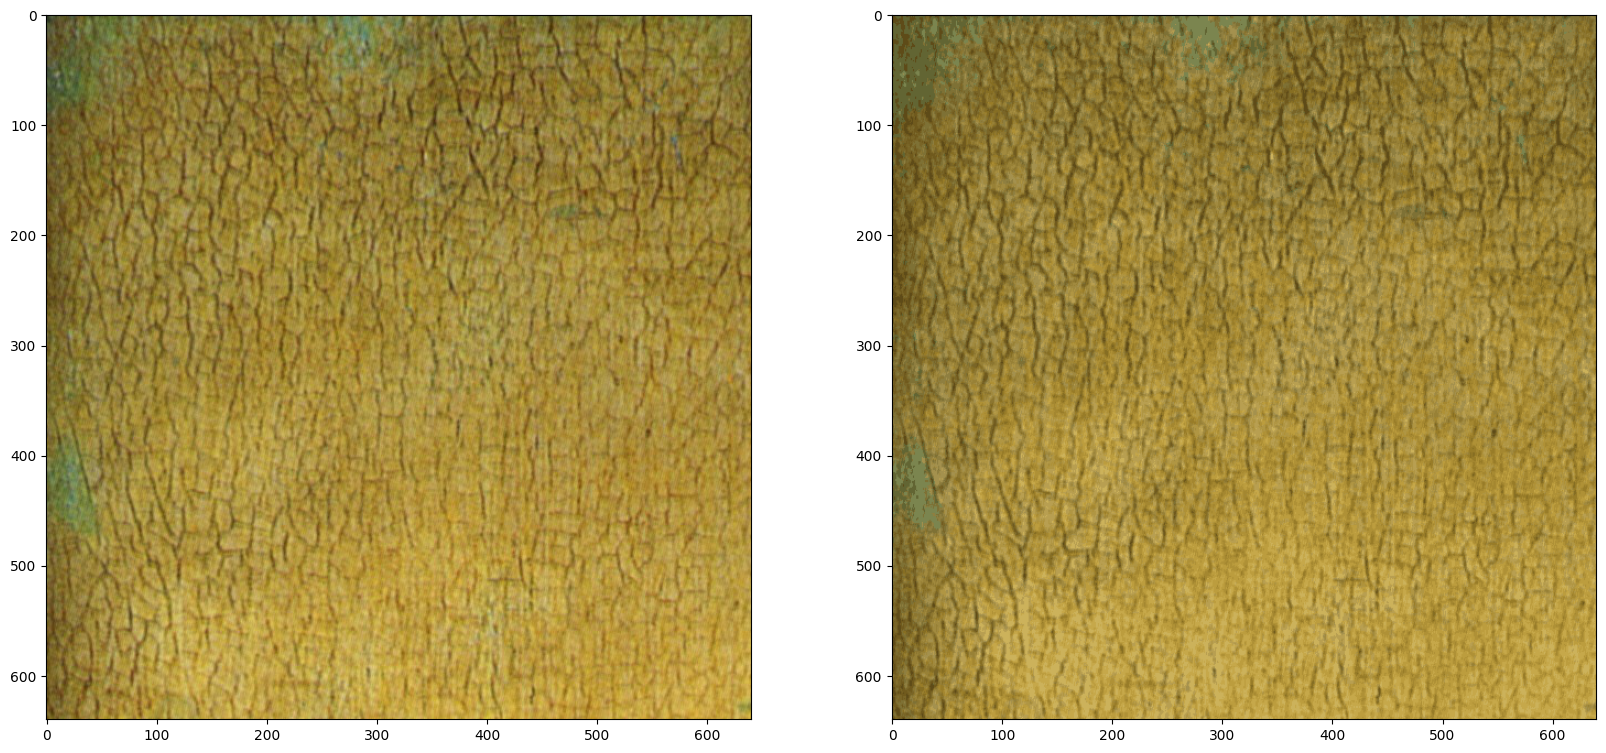

In [43]:
show_img_bbox(image[:image_shape_out[0],\
                     :image_shape_out[1], \
                        :image_shape_out[2]], y_image)

#### c = 10

##### fit

In [44]:
model = FuzzyCMeansGaussianS2(num_class=10, epochs=50, threshold=.5, verbose=True)
model.fit(X, None)

epoca: 0 funcão objetivo: 62590.67191153858
epoca: 1 funcão objetivo: 1549.7322295155568
epoca: 2 funcão objetivo: 1324.191473221383
epoca: 3 funcão objetivo: 1225.55016412733
epoca: 4 funcão objetivo: 1180.9017608920344
epoca: 5 funcão objetivo: 1143.6222257306968
epoca: 6 funcão objetivo: 1117.7129188650265
epoca: 7 funcão objetivo: 1098.1560519177763
epoca: 8 funcão objetivo: 1080.5084820733375
epoca: 9 funcão objetivo: 1066.5733158357052
epoca: 10 funcão objetivo: 1054.0324869342858
epoca: 11 funcão objetivo: 1043.1435418192518
epoca: 12 funcão objetivo: 1033.526960803067
epoca: 13 funcão objetivo: 1024.4513992506663
epoca: 14 funcão objetivo: 1017.0313915346306
epoca: 15 funcão objetivo: 1009.6821683613413
epoca: 16 funcão objetivo: 1004.0273729667801
epoca: 17 funcão objetivo: 998.2433712090948
epoca: 18 funcão objetivo: 993.8313059075101
epoca: 19 funcão objetivo: 989.3470589240784
epoca: 20 funcão objetivo: 985.7307416754139
epoca: 21 funcão objetivo: 982.2338630349052
epoca: 2

In [45]:
model.G

array([[0.5777707 , 0.50889022, 0.24798095],
       [0.73815749, 0.62539842, 0.27615116],
       [0.62859401, 0.52418882, 0.19869258],
       [0.7867641 , 0.67868685, 0.33386467],
       [0.48563325, 0.40090958, 0.14367716],
       [0.39783454, 0.33095164, 0.11954047],
       [0.6569563 , 0.57140883, 0.28559369],
       [0.47338902, 0.45410637, 0.23087806],
       [0.69150477, 0.57671284, 0.22461361],
       [0.55708904, 0.46441824, 0.17212911]])

In [46]:
model.sigma

array([[0.9690103 , 1.1783553 , 0.87578064],
       [0.94615775, 1.3653878 , 0.7740704 ],
       [1.0702732 , 1.1640525 , 0.80266213],
       [0.9632715 , 1.2559013 , 0.8266007 ],
       [0.9634551 , 1.1491244 , 0.90323657],
       [0.92290807, 1.1552055 , 0.9379556 ],
       [0.98956776, 1.2588779 , 0.8027325 ],
       [0.8984683 , 1.1502849 , 0.9675909 ],
       [0.90557015, 1.1789542 , 0.9366578 ],
       [0.9649514 , 1.2072003 , 0.8584505 ]], dtype=float32)

In [64]:
# y = model.predict(image.reshape(-1, image_shape_out[2])/255)
y = model.predict(X)

In [65]:
y_image = (model.G[y].reshape(image_shape_out)*255).astype(np.uint8)

In [66]:
filename = img_path.split("/")[-1]
set_name = "results/minimal_v3/cmeans/art/"
model.save_model(f"{set_name}model/10/model.json")

dir_out_img = f"{set_name}imgs/10/"
if not os.path.isfile(dir_out_img):
    os.makedirs(dir_out_img, exist_ok=True)

Image.fromarray(y_image).save(f"{dir_out_img}{filename}")
ssim, hssim, q = metricas(
    image[: image_shape_out[0], : image_shape_out[1], : image_shape_out[2]], y_image
) # 
resultados.append([ssim, hssim, q])
# metricas(image, y_image)

SSIM : 0.9433
SSIM entre histogramas: 0.1623
UQI: 0.9900


##### show

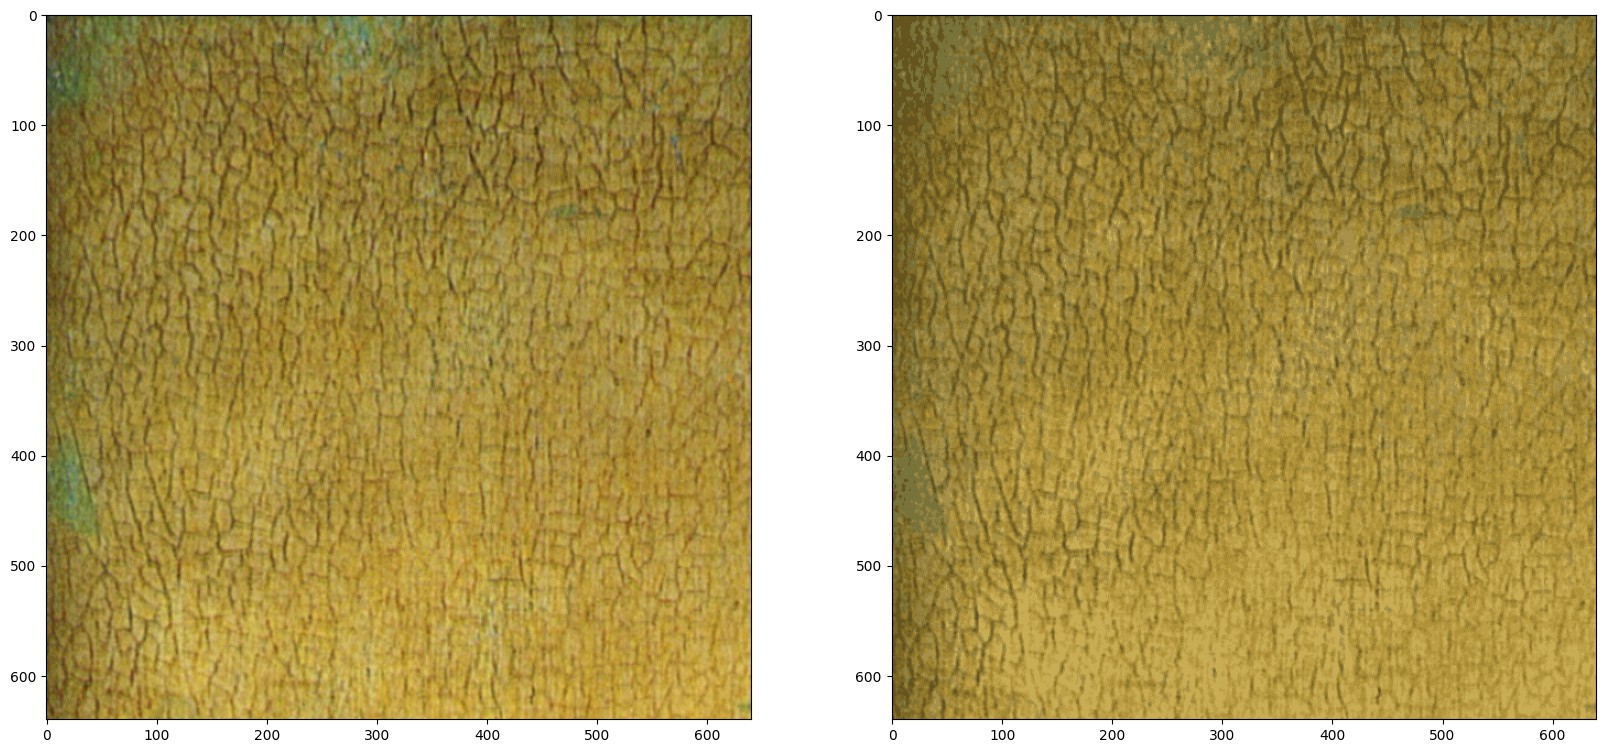

In [67]:
show_img_bbox(image[:image_shape_out[0],\
                     :image_shape_out[1], \
                        :image_shape_out[2]], y_image)

In [68]:
# time change
# new row
# new column
# pure grid
# ecs_insert
# whole_row
# whole_column


In [69]:
pd.DataFrame(
    np.array(resultados).T, index=["ssim", "hssim", "uqi"]
).T.to_csv(f"results/minimal_v3/cmeans/metricas.csv")
print(resultados)

[[0.8044970551635116, 0.2379480057424096, 0.9971154753195399], [0.5731413564652763, 0.19608349129664795, 0.9948936794334343], [0.9654128341023624, 0.24428505524757438, 0.9939923187880599], [0.9432676513203635, 0.16230848720376898, 0.9899994466234651], [0.8836321552367562, 0.0034740286813097106, 0.7015169103536643], [0.9432676513203635, 0.16230848720376898, 0.9899994466234651]]


In [ ]:
recorte do painel
possibilidade de fazer reducão com o minimo de perdas do "dithering"
metricas
